# Gaussian Process Regression

Реализуется регрессия на Gaussian Process с нуля на NumPy:
от `RBF kernel` до подбора гиперпараметров по marginal likelihood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return current.parent if current.name == "notebooks" else current


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures" / "gaussian_process"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print("Папка для графиков:", FIGURES_DIR)
print("Версия NumPy:", np.__version__)
print("Базовая настройка готова.")


Папка для графиков: /Users/nailloon/Documents/Projects/study/deep_learning/repository/figures/gaussian_process
Версия NumPy: 2.4.6
Базовая настройка готова.


In [2]:
# Реализация RBF kernel
# k(x1, x2) = sigma_f^2 * exp(-||x1 - x2||^2 / (2 * l^2))


def rbf_kernel(X1, X2, length_scale, sigma_f):
    """
    Считает матрицу RBF kernel между X1 и X2.

    Parameters
    ----------
    X1 : ndarray of shape (n1, d)
    X2 : ndarray of shape (n2, d)
    length_scale : float
        Controls the smoothness / correlation length (l).
    sigma_f : float
        Signal standard deviation; scales the overall variance.

    Returns
    -------
    K : ndarray of shape (n1, n2)
        Матрица Грама.
    """
    X1_sq = np.sum(X1 ** 2, axis=1, keepdims=True)
    X2_sq = np.sum(X2 ** 2, axis=1, keepdims=True).T
    sq_dists = X1_sq + X2_sq - 2.0 * (X1 @ X2.T)
    sq_dists = np.maximum(sq_dists, 0.0)

    K = sigma_f ** 2 * np.exp(-sq_dists / (2.0 * length_scale ** 2))
    return K


X_demo = np.array([[0.0], [1.0], [2.0]])
K_demo = rbf_kernel(X_demo, X_demo, length_scale=1.0, sigma_f=1.0)
print("Проверочная kernel-матрица (3x3):")
print(np.round(K_demo, 4))
print("Диагональ должна быть равна 1.0 при sigma_f=1:", np.round(np.diag(K_demo), 4))


Проверочная kernel-матрица (3x3):
[[1.     0.6065 0.1353]
 [0.6065 1.     0.6065]
 [0.1353 0.6065 1.    ]]
Диагональ должна быть равна 1.0 при sigma_f=1: [1. 1. 1.]


In [3]:
# Предсказание GP
# Для учебной задачи ниже используем интерполяционный GP без observation noise.
# Матрицу K(X, X) обращаем явно, но считаем это устойчиво через разложение Холецкого.


def invert_spd_matrix(K):
    """
    Устойчиво обращает симметричную положительно определённую матрицу.

    Для учебной цели возвращаем явную матрицу K^{-1}; в production-коде
    обычно предпочитают solve без построения обратной матрицы.
    """
    L = np.linalg.cholesky(K)
    identity = np.eye(K.shape[0])
    K_inv = np.linalg.solve(L.T, np.linalg.solve(L, identity))
    return K_inv



def gp_predict(X_train, y_train, X_test, length_scale, sigma_f, jitter=1e-12):
    """
    Интерполяционное предсказание в Gaussian Process.

    Parameters
    ----------
    X_train : ndarray (n, d)
    y_train : ndarray (n,)
    X_test  : ndarray (m, d)
    length_scale : float
    sigma_f      : float
    jitter       : float
        Малый численный шум только для устойчивости матрицы K(X, X).

    Returns
    -------
    mu_pred   : ndarray (m,)    предиктивное среднее
    var_pred  : ndarray (m,)    диагональ предиктивной ковариации
    cov_pred  : ndarray (m, m)  полная предиктивная ковариация
    K_train   : ndarray (n, n)  kernel-матрица обучающих точек
    K_inv     : ndarray (n, n)  обратная матрица K_train^{-1}
    """
    n = len(X_train)

    K_train = rbf_kernel(X_train, X_train, length_scale, sigma_f)
    K_train += jitter * np.eye(n)

    K_train_test = rbf_kernel(X_train, X_test, length_scale, sigma_f)
    K_test_test = rbf_kernel(X_test, X_test, length_scale, sigma_f)

    K_inv = invert_spd_matrix(K_train)

    mu_pred = K_train_test.T @ K_inv @ y_train
    cov_pred = K_test_test - K_train_test.T @ K_inv @ K_train_test

    # Симметризуем ковариацию после численных операций.
    cov_pred = 0.5 * (cov_pred + cov_pred.T)
    var_pred = np.clip(np.diag(cov_pred), 0.0, None)

    return mu_pred, var_pred, cov_pred, K_train, K_inv


print("Функции invert_spd_matrix и gp_predict готовы.")
print("Для предсказания используем явную обратную матрицу K^{-1}, посчитанную через Холецкого.")


Функции invert_spd_matrix и gp_predict готовы.
Для предсказания используем явную обратную матрицу K^{-1}, посчитанную через Холецкого.


In [4]:
# Marginal likelihood
# log p(y | X, theta) = -0.5 y^T K^{-1} y - 0.5 log|K| - n/2 log(2*pi)
# Оптимизируем только гиперпараметры ядра: length_scale и sigma_f.


def negative_log_marginal_likelihood(log_params, X_train, y_train, jitter=1e-12):
    """
    Считает отрицательный log marginal likelihood для интерполяционного GP.

    Параметры передаются в логарифмическом масштабе:
        log_params = [log(length_scale), log(sigma_f)]
    """
    length_scale, sigma_f = np.exp(log_params)
    n = len(X_train)

    K = rbf_kernel(X_train, X_train, length_scale, sigma_f)
    K += jitter * np.eye(n)

    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return 1e12

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    log_det = 2.0 * np.sum(np.log(np.diag(L)))

    nlml = 0.5 * y_train @ alpha + 0.5 * log_det + 0.5 * n * np.log(2.0 * np.pi)
    return float(nlml)


print("Функция negative_log_marginal_likelihood готова.")
print("Оптимизируем только гиперпараметры ядра, а jitter используем лишь для устойчивости.")


Функция negative_log_marginal_likelihood готова.
Оптимизируем только гиперпараметры ядра, а jitter используем лишь для устойчивости.


## Почему здесь нет observation noise

Критерий приёмки требует, чтобы неопределённость в обучающих точках была нулевой.
Поэтому ниже используется **интерполяционный Gaussian Process**: наблюдения считаются точными,
а в матрицу `K(X, X)` добавляется только очень маленький `jitter` для численной устойчивости.

Такой `jitter` не является моделью шума измерений и лишь помогает устойчиво выполнить
разложение Холецкого и обращение матрицы.


Учебные данные:
  X_train shape: (7, 1)
  y_train shape: (7,)
  X_test  shape: (407, 1)
  Данные без observation noise: GP должен интерполировать точки.


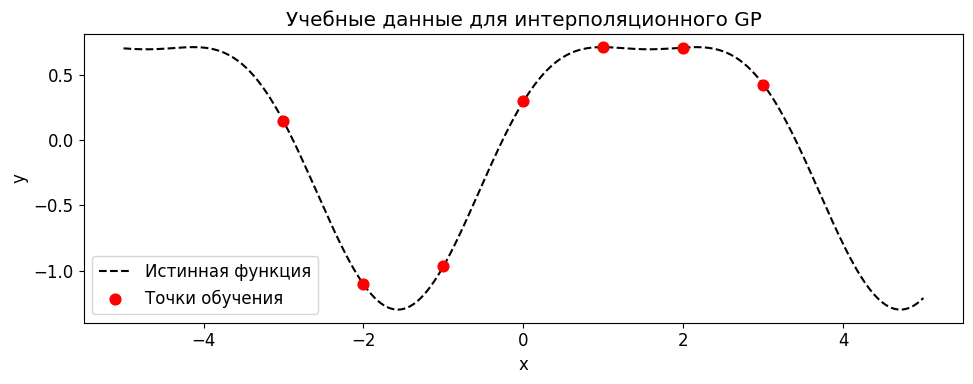

In [5]:
# Генерируем учебные данные
# Берём точные значения функции, чтобы GP интерполировал обучающие точки.


def true_function(x):
    return np.sin(x) + 0.3 * np.cos(2 * x)


X_train = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float).reshape(-1, 1)
y_train = true_function(X_train.ravel())

X_test_dense = np.linspace(-5, 5, 400)
X_test = np.sort(np.unique(np.concatenate([X_test_dense, X_train.ravel()]))).reshape(-1, 1)
y_true = true_function(X_test.ravel())

print("Учебные данные:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_test  shape: {X_test.shape}")
print("  Данные без observation noise: GP должен интерполировать точки.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(X_test.ravel(), y_true, 'k--', label='Истинная функция', linewidth=1.5)
ax.scatter(X_train.ravel(), y_train, color='red', zorder=5, s=60, label='Точки обучения')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Учебные данные для интерполяционного GP')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_data.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# Подбор гиперпараметров по marginal likelihood
# Используем несколько стартов, чтобы не зависеть от одной инициализации.

initial_guesses = np.array([
    [0.3, 0.5],
    [0.7, 1.0],
    [1.0, 1.0],
    [2.5, 1.5],
], dtype=float)
log_initial_guesses = np.log(initial_guesses)

bounds = [
    (np.log(1e-2), np.log(1e2)),
    (np.log(1e-2), np.log(1e2)),
]

print("Стартовые точки оптимизации (length_scale, sigma_f):")
for guess in initial_guesses:
    print(f"  ({guess[0]:.2f}, {guess[1]:.2f})")
print()

results = []
successful_results = []
for i, x0 in enumerate(log_initial_guesses, start=1):
    result = minimize(
        negative_log_marginal_likelihood,
        x0=x0,
        args=(X_train, y_train),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-8}
    )
    results.append(result)

    ls_i, sigma_i = np.exp(result.x)
    status = 'OK' if result.success else 'IGNORED'
    print(
        f"Старт {i} [{status}]: length_scale={ls_i:.4f}, "
        f"sigma_f={sigma_i:.4f}, neg. LML={result.fun:.6f}"
    )

    if result.success:
        successful_results.append(result)

if not successful_results:
    raise RuntimeError('Ни один запуск оптимизации не завершился успешно.')

best_result = min(successful_results, key=lambda res: res.fun)
opt_length_scale, opt_sigma_f = np.exp(best_result.x)
ignored_runs = len(results) - len(successful_results)

print()
print("Лучший результат оптимизации:")
print(f"  Success: {best_result.success}")
print(f"  Message: {best_result.message}")
print(f"  length_scale = {opt_length_scale:.6f}")
print(f"  sigma_f      = {opt_sigma_f:.6f}")
print(f"  Оптимальный neg. LML = {best_result.fun:.6f}")
print(f"  Отброшено неуспешных стартов: {ignored_runs}")

hit_lower_bound = any(np.isclose(best_result.x[i], bounds[i][0], atol=1e-6) for i in range(2))
hit_upper_bound = any(np.isclose(best_result.x[i], bounds[i][1], atol=1e-6) for i in range(2))
print(f"  Решение на границе bounds: {hit_lower_bound or hit_upper_bound}")


Стартовые точки оптимизации (length_scale, sigma_f):
  (0.30, 0.50)
  (0.70, 1.00)
  (1.00, 1.00)
  (2.50, 1.50)

Старт 1 [IGNORED]: length_scale=1.1820, sigma_f=0.7743, neg. LML=5.075064
Старт 2 [OK]: length_scale=1.1820, sigma_f=0.7743, neg. LML=5.075064
Старт 3 [OK]: length_scale=1.1820, sigma_f=0.7743, neg. LML=5.075064
Старт 4 [OK]: length_scale=0.0100, sigma_f=0.7044, neg. LML=7.480099

Лучший результат оптимизации:
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  length_scale = 1.181955
  sigma_f      = 0.774330
  Оптимальный neg. LML = 5.075064
  Отброшено неуспешных стартов: 1
  Решение на границе bounds: False


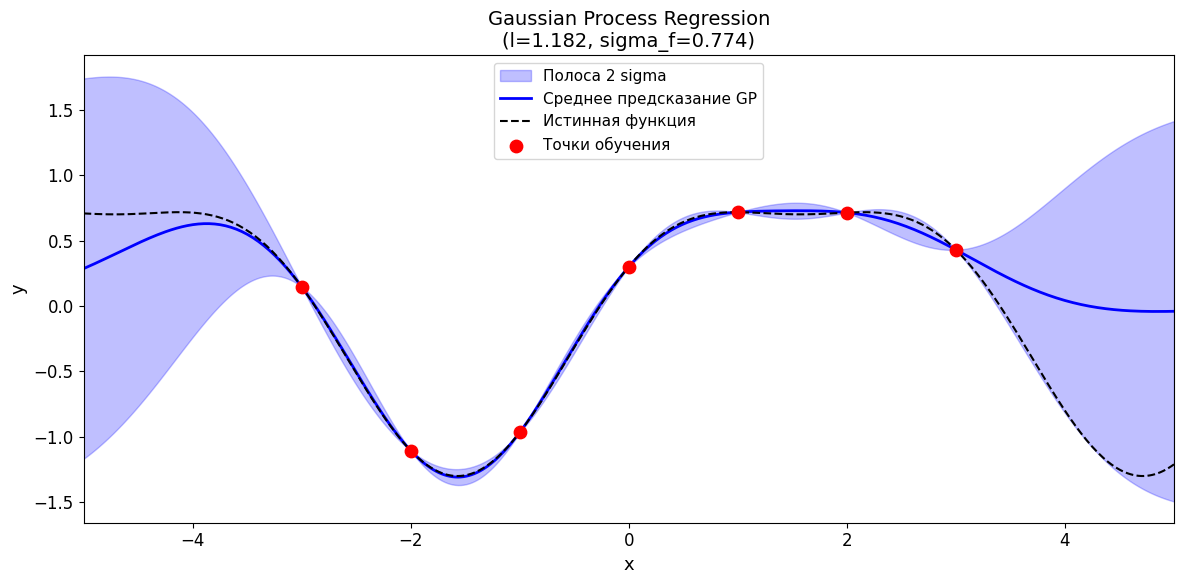

Размер kernel-матрицы K(X, X): (7, 7)
Размер обратной матрицы K(X, X)^(-1): (7, 7)
Наблюдение: неопределённость схлопывается в обучающих точках и растёт между ними и вне диапазона данных.


In [7]:
# Предсказание и визуализация с подобранными параметрами

mu_pred, var_pred, cov_pred, K_train, K_inv = gp_predict(
    X_train,
    y_train,
    X_test,
    length_scale=opt_length_scale,
    sigma_f=opt_sigma_f,
)
std_pred = np.sqrt(var_pred)
x_plot = X_test.ravel()

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(
    x_plot,
    mu_pred - 2.0 * std_pred,
    mu_pred + 2.0 * std_pred,
    alpha=0.25,
    color='blue',
    label='Полоса 2 sigma'
)
ax.plot(x_plot, mu_pred, 'b-', linewidth=2, label='Среднее предсказание GP')
ax.plot(x_plot, y_true, 'k--', linewidth=1.5, label='Истинная функция')
ax.scatter(X_train.ravel(), y_train, color='red', zorder=5, s=80, label='Точки обучения')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title(
    f'Gaussian Process Regression\n'
    f'(l={opt_length_scale:.3f}, sigma_f={opt_sigma_f:.3f})',
    fontsize=14,
)
ax.legend(fontsize=11)
ax.set_xlim(-5, 5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gp_regression.png', dpi=120, bbox_inches='tight')
plt.show()

print("Размер kernel-матрицы K(X, X):", K_train.shape)
print("Размер обратной матрицы K(X, X)^(-1):", K_inv.shape)
print("Наблюдение: неопределённость схлопывается в обучающих точках и растёт между ними и вне диапазона данных.")


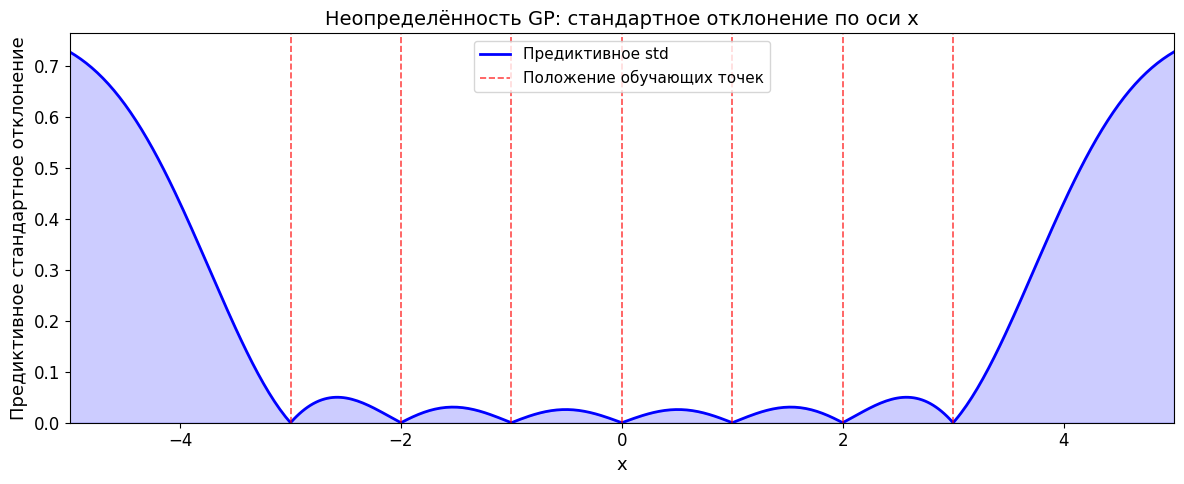

Стандартное отклонение в точных обучающих точках:
  x = -3  -->  std = 0.00000100
  x = -2  -->  std = 0.00000100
  x = -1  -->  std = 0.00000100
  x = +0  -->  std = 0.00000100
  x = +1  -->  std = 0.00000100
  x = +2  -->  std = 0.00000100
  x = +3  -->  std = 0.00000100

Максимум std внутри интервалов между соседними обучающими точками:
  (-3, -2) --> max std = 0.049904 at x = -2.569
  (-2, -1) --> max std = 0.030623 at x = -1.541
  (-1, +0) --> max std = 0.025840 at x = -0.514
  (+0, +1) --> max std = 0.025840 at x = +0.514
  (+1, +2) --> max std = 0.030623 at x = +1.541
  (+2, +3) --> max std = 0.049904 at x = +2.569

Максимальная асимметрия cov_pred: 0.000e+00
Минимальное собственное значение cov_pred: -1.682e-14


In [8]:
# График неопределённости и численные проверки критерия приёмки

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_plot, std_pred, 'b-', linewidth=2, label='Предиктивное std')
ax.fill_between(x_plot, 0, std_pred, alpha=0.2, color='blue')

for i, x_t in enumerate(X_train.ravel()):
    label = 'Положение обучающих точек' if i == 0 else None
    ax.axvline(x=x_t, color='red', linestyle='--', alpha=0.7, linewidth=1.2, label=label)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('Предиктивное стандартное отклонение', fontsize=13)
ax.set_title('Неопределённость GP: стандартное отклонение по оси x', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(-5, 5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'uncertainty_curve.png', dpi=120, bbox_inches='tight')
plt.show()

train_x_vals = X_train.ravel()
train_idxs = [np.where(np.isclose(x_plot, xt))[0][0] for xt in train_x_vals]
train_std = std_pred[train_idxs]

print("Стандартное отклонение в точных обучающих точках:")
for xt, std in zip(train_x_vals, train_std):
    print(f"  x = {xt:+.0f}  -->  std = {std:.8f}")

print() 
print("Максимум std внутри интервалов между соседними обучающими точками:")
for left, right in zip(train_x_vals[:-1], train_x_vals[1:]):
    mask = (x_plot > left) & (x_plot < right)
    local_std = std_pred[mask]
    local_x = x_plot[mask]
    max_idx = np.argmax(local_std)
    print(
        f"  ({left:+.0f}, {right:+.0f}) --> max std = {local_std[max_idx]:.6f} "
        f"at x = {local_x[max_idx]:+.3f}"
    )

cov_symmetry_error = np.max(np.abs(cov_pred - cov_pred.T))
min_eig = np.min(np.linalg.eigvalsh(cov_pred))
print()
print(f"Максимальная асимметрия cov_pred: {cov_symmetry_error:.3e}")
print(f"Минимальное собственное значение cov_pred: {min_eig:.3e}")


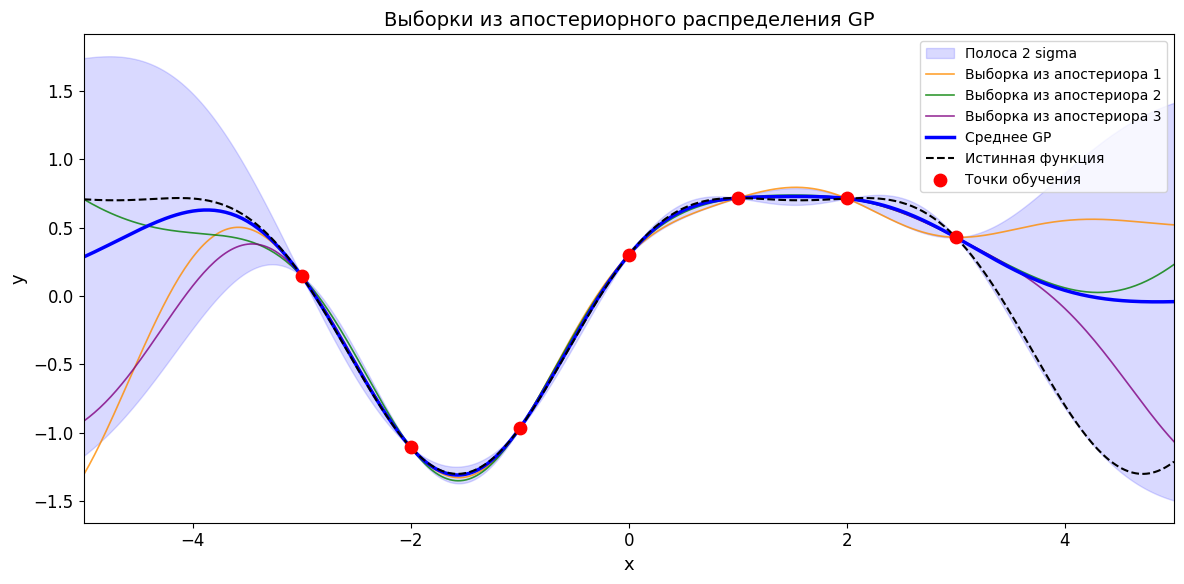

Максимальное отклонение выборок от обучающих точек: 3.341e-06
В интерполяционном GP это отклонение равно численной погрешности, а не observation noise.


In [9]:
# Выборки из апостериорного GP
# Здесь X_test содержит и плотную сетку, и сами обучающие точки,
# поэтому можно строго проверить, что выборки проходят через них.

np.random.seed(0)
n_samples = 3

cov_stable = cov_pred + 1e-12 * np.eye(len(X_test))
posterior_samples = np.random.multivariate_normal(
    mean=mu_pred,
    cov=cov_stable,
    size=n_samples,
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(
    x_plot,
    mu_pred - 2.0 * std_pred,
    mu_pred + 2.0 * std_pred,
    alpha=0.15,
    color='blue',
    label='Полоса 2 sigma'
)

colors = ['darkorange', 'green', 'purple']
for i, sample in enumerate(posterior_samples):
    ax.plot(
        x_plot,
        sample,
        color=colors[i],
        linewidth=1.2,
        alpha=0.8,
        linestyle='-',
        label=f'Выборка из апостериора {i + 1}'
    )

ax.plot(x_plot, mu_pred, 'b-', linewidth=2.5, label='Среднее GP')
ax.plot(x_plot, y_true, 'k--', linewidth=1.5, label='Истинная функция')
ax.scatter(X_train.ravel(), y_train, color='red', zorder=5, s=80, label='Точки обучения')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Выборки из апостериорного распределения GP', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-5, 5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'posterior_samples.png', dpi=120, bbox_inches='tight')
plt.show()

train_values_from_samples = posterior_samples[:, train_idxs]
max_train_deviation = np.max(np.abs(train_values_from_samples - y_train))
print(f"Максимальное отклонение выборок от обучающих точек: {max_train_deviation:.3e}")
print("В интерполяционном GP это отклонение равно численной погрешности, а не observation noise.")


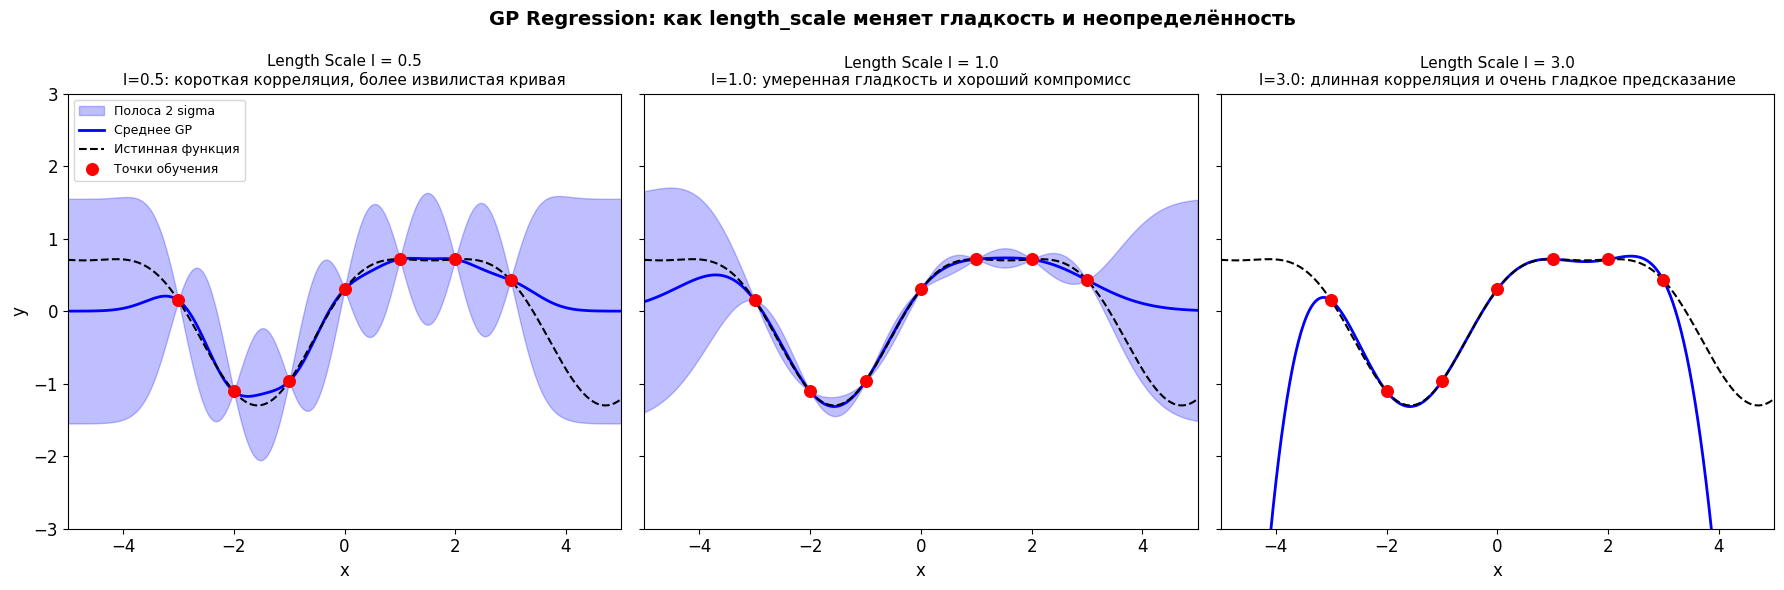

Коротко по влиянию length_scale:
  l=0.5 --> Каждая обучающая точка влияет в основном на локальную окрестность.
  l=1.0 --> Получается более сбалансированная гладкость кривой.
  l=3.0 --> Корреляция длинная, поэтому предсказание становится заметно более гладким.


In [10]:
# Чувствительность к length_scale
# Сравниваем три значения length_scale, sigma_f оставляем оптимальным.

length_scales = [0.5, 1.0, 3.0]
descriptions = [
    'l=0.5: короткая корреляция, более извилистая кривая',
    'l=1.0: умеренная гладкость и хороший компромисс',
    'l=3.0: длинная корреляция и очень гладкое предсказание',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, ls, desc in zip(axes, length_scales, descriptions):
    mu, var, _, _, _ = gp_predict(
        X_train,
        y_train,
        X_test,
        length_scale=ls,
        sigma_f=opt_sigma_f,
    )
    std = np.sqrt(var)

    ax.fill_between(
        x_plot,
        mu - 2.0 * std,
        mu + 2.0 * std,
        alpha=0.25,
        color='blue',
        label='Полоса 2 sigma'
    )
    ax.plot(x_plot, mu, 'b-', linewidth=2, label='Среднее GP')
    ax.plot(x_plot, y_true, 'k--', linewidth=1.5, label='Истинная функция')
    ax.scatter(X_train.ravel(), y_train, color='red', zorder=5, s=70, label='Точки обучения')
    ax.set_title(f'Length Scale l = {ls}\n{desc}', fontsize=11)
    ax.set_xlabel('x', fontsize=12)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel('y', fontsize=12)
axes[0].legend(fontsize=9, loc='upper left')
fig.suptitle(
    'GP Regression: как length_scale меняет гладкость и неопределённость',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'length_scale_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

print("Коротко по влиянию length_scale:")
print("  l=0.5 --> Каждая обучающая точка влияет в основном на локальную окрестность.")
print("  l=1.0 --> Получается более сбалансированная гладкость кривой.")
print("  l=3.0 --> Корреляция длинная, поэтому предсказание становится заметно более гладким.")
